(20000, 32)
TFIDF Shape: (20000, 5000)
Final Feature Shape: (20000, 5006)
(16000, 5006) (4000, 5006)

ACCURACY
0.6245

F1 SCORE
0.7124808575803981

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.54      0.40      0.46      1598
           1       0.66      0.77      0.71      2402

    accuracy                           0.62      4000
   macro avg       0.60      0.59      0.59      4000
weighted avg       0.61      0.62      0.61      4000


CONFUSION MATRIX
[[ 637  961]
 [ 541 1861]]


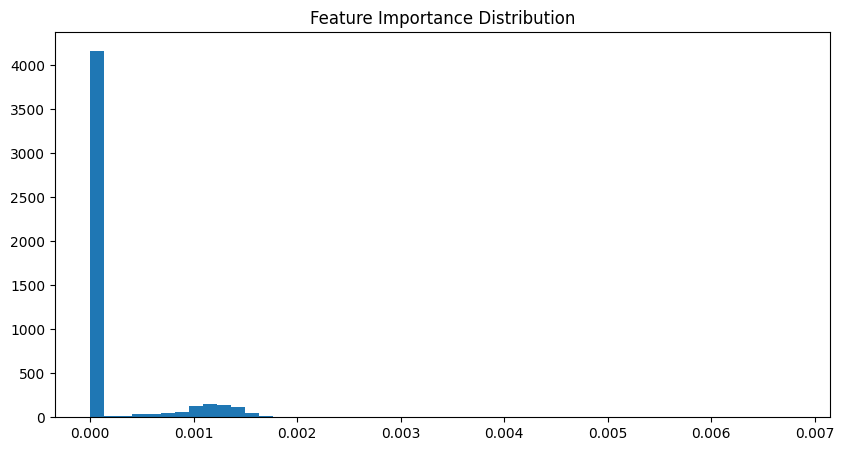


Model Saved Successfully


In [1]:
# ==========================================
# PHASE 3
# TF-IDF + XGBoost Mismatch Detection
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder

from scipy.sparse import hstack

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(
    "pseudo_labeled_tickets.csv"
)

print(df.shape)

# ==========================================
# TARGET
# ==========================================

y = df["mismatch"]

# ==========================================
# TEXT FEATURES
# ==========================================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_text = tfidf.fit_transform(
    df["clean_text"]
)

print(
    "TFIDF Shape:",
    X_text.shape
)

# ==========================================
# ENCODE CATEGORICAL FEATURES
# ==========================================

cat_cols = [

    "Issue_Category",
    "Ticket_Channel"

]

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = le

# ==========================================
# NUMERICAL FEATURES
# ==========================================

numeric_features = [

    "Resolution_Time_Hours",

    "Satisfaction_Score",

    "subject_length",

    "description_length",

    "Issue_Category",

    "Ticket_Channel"

]

X_num = df[
    numeric_features
]

# ==========================================
# COMBINE FEATURES
# ==========================================

X = hstack([
    X_text,
    X_num
])

print(
    "Final Feature Shape:",
    X.shape
)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(
    X_train.shape,
    X_test.shape
)

# ==========================================
# XGBOOST MODEL
# ==========================================

model = XGBClassifier(

    n_estimators=500,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"

)

# ==========================================
# TRAIN
# ==========================================

model.fit(
    X_train,
    y_train
)

# ==========================================
# PREDICT
# ==========================================

preds = model.predict(
    X_test
)

# ==========================================
# EVALUATION
# ==========================================

acc = accuracy_score(
    y_test,
    preds
)

f1 = f1_score(
    y_test,
    preds
)

print("\n===================")
print("ACCURACY")
print("===================")

print(acc)

print("\n===================")
print("F1 SCORE")
print("===================")

print(f1)

print("\n===================")
print("CLASSIFICATION REPORT")
print("===================")

print(
    classification_report(
        y_test,
        preds
    )
)

print("\n===================")
print("CONFUSION MATRIX")
print("===================")

print(
    confusion_matrix(
        y_test,
        preds
    )
)

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(
    figsize=(10,5)
)

plt.hist(
    importance,
    bins=50
)

plt.title(
    "Feature Importance Distribution"
)

plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

import joblib

joblib.dump(
    model,
    "xgb_mismatch_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print(
    "\nModel Saved Successfully"
)